# Pump

The pump is defined as a »device for generating pressure differences within liquids«. There exist a large number of different pump types, which are distinguished on the basis of their operating principle, e.g. buoyancy pumps, friction pumps, flow pumps, jet pumps, sorption pumps and diffusion pumps, which will not be discussed in detail here. Important characteristics of pumps are the flow rate $q$ and the delivery head $h$. The head is the pressure difference generated by the pump, which is usually converted into a height using the equation for hydrostatic pressure. Delivery head and delivery flow are interdependent. The representation of the function $h(q)$ is also called pump characteristic.
Here, an actuating signal is applied, based on which the pump adjusts a defined volume flow $q$.

<img src = "./model.svg" width=150px>

## Model equations

$$\dot q = q_{min} + c \cdot (q_{max} - q_{min})$$

A simple algebraic model is formulated accordingly for the pump, which determines the volume flow $q$ on the basis of the time-dependent manipulated variable $c(t)$. This leads to the following equation:

$$q=q_{min}+f(t)\cdot q_{max}-q_{min}$$

Here, $q_{min}$ and $q_{max}$ represent the minimum and maximum achievable flow rate of the pump, with:

$$f(t)=\frac{c(t)-c_{min}}{c_{max}-c_{min}}$$

$f(t)$ is the flow rate control value and is normalized to the interval $[0.0, 1.0]$. The manipulated value is limited  to $c_{min}$ and $c_{max}$, e.g. to 4.0 mA and 20.0 mA (see also DIN IEC 60381-1).

Overall this results in:

$$q=q_{min}+\frac{c(t)-c_{min}}{c_{max}-c_{min}}\cdot q_{max}-q_{min}$$

## Parameters

The equations will be computed with the follwing parameters.

| Parameter | Symbol | Value | Unit | 
| :------- | :----: | :---: | :---- |
| Volumtric flow limits | $q_{min}$, $q_{max}$ | 0 - 0.005 | m³/h |
| Manipulated value limits | $c_{min}$, $c_{max}$ | 4.0 - 20.0 | mA |



## Implementation of the model


In [1]:
from simunetcore import Model
import numpy as np

# Model implementation for the Tank
class Pump(Model):
    def __init__(self, name:str=""):
        Model.__init__(self, name)

        # Model parameters
        self.params = {
            # Parameters pump
            "c_range": {"value": [4.0, 20.0], "description": "Range of control value", "unit": "mA"},
            "q_range": {"value": [0.0, 0.005], "description": "Range of flow rate", "unit": "m³\s"}
        }
        # Model variables
        self.vars = {
            "c": {"description": "Control value", "unit": "mA"},
            "q": {"description": "Flow Rate", "unit": "m³/s"} 
        }
        # Model inputs
        self.u = {
            "u_1": {"type": "liquid", "description": "Pump feed input", "vars": []},
            "u_2": {"type": "control", "description": "Control value input", "vars": ["c"]}
        }
        # Model outputs
        self.y = {
            "y_1": {"type": "liquid", "description": "Pump output", "vars": ["q"]}
        }
        # Port adjacencies
        self.adj = [
            ["u_1", "y_1"]
        ]
             
    def compute(self, *args, **kwargs):
        # Get parameter q_range
        q_range = self.get_param("q_range") # Range of flow rate [m³\s]
        c_range = self.get_param("c_range") # Range of control value [mA]
        
        # Get control value
        c = self.get_var("c")
        c = np.maximum(np.minimum(c, c_range[-1]), c_range[0])
        c = (c-c_range[0])/(c_range[-1]-c_range[0])
        
        # Compute flow
        q = np.ones(c.shape)*q_range[0] + c*(q_range[-1]-q_range[0])

        # Store results
        self.set_var("q", q)


## Computation of the model

In [2]:
# Create model
M_3 = Pump("M_3")

# Setup integration time
t_start = 0.0
t_end = 300.0
numpoints = 51
M_3.set_t(np.linspace(t_start, t_end, numpoints))

# Setup imput vector
c = np.linspace(1.0, 30, numpoints)
u_2 = [c]
M_3.set_u("u_2", u_2)

# Solve model
M_3.compute()

## Results

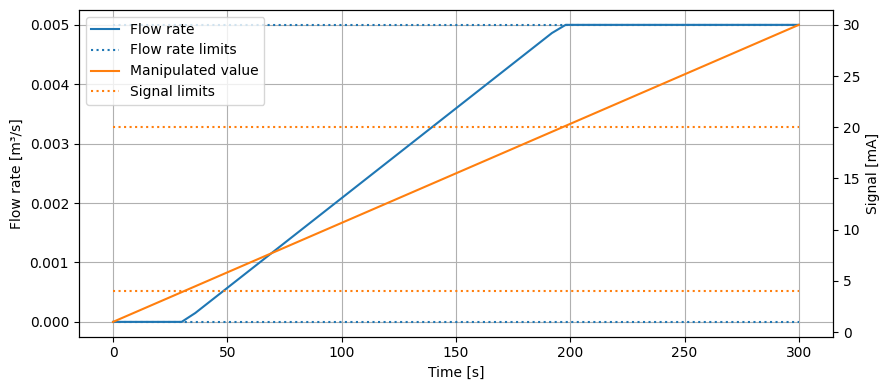

In [4]:
import matplotlib
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(9, 4))

# Plot values
ln_1 = plt.plot(M_3.get_t(), M_3.get_var("q"), "C0", label="Flow rate")
ln_1_1 = plt.plot(
    [M_3.get_t()[0], M_3.get_t()[-1]], 
    [M_3.get_param("q_range")[0], M_3.get_param("q_range")[0]], 
    "C0:", label="Flow rate limits")
plt.plot(
    [M_3.get_t()[0], M_3.get_t()[-1]], 
    [M_3.get_param("q_range")[-1], M_3.get_param("q_range")[-1]], 
    "C0:")
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("Flow rate [m³/s]")

# Second axis
plt.twinx()

ln_2=plt.plot(M_3.get_t(), M_3.get_var("c"), "C1", label="Manipulated value")
ln_2_2=plt.plot(
    [M_3.get_t()[0], M_3.get_t()[-1]], 
    [M_3.get_param("c_range")[0], M_3.get_param("c_range")[0]], 
    "C1:", label="Signal limits")
plt.plot(
    [M_3.get_t()[0], M_3.get_t()[-1]], 
    [M_3.get_param("c_range")[-1], M_3.get_param("c_range")[-1]], 
    "C1:")
plt.ylabel('Signal [mA]')

# Show legend
lines = ln_1 + ln_1_1 + ln_2 + ln_2_2
labels = [line.get_label() for line in lines]
plt.legend(lines, labels, loc=2)  

# Layout and show
plt.tight_layout()
plt.show()